# ColBERTv2 vs Bi-Encoder Retrieval Benchmark

End-to-end pipeline: data loading → chunking → NER classification → bi-encoder retrieval → ColBERTv2 retrieval → evaluation → visualization.

All results are written to a single JSON log file. Evaluation and visualization read exclusively from that log.

In [1]:
import os, sys
from pathlib import Path
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import json
import yaml
import pandas as pd
from IPython.display import Image, display

from src.profiler import Profiler
from src.benchmark_runner import load_config, build_variant_config, run_full_benchmark

config = load_config("configs/experiment_config.yaml")

print("Config loaded.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Default chunking strategy: {config['chunking']['strategy']}")


Config loaded.
Project root: c:\Users\DXY\Downloads\1508-project-dev
Default chunking strategy: paragraph


## 1. Data Pipeline

Load KILT NQ, build reduced corpus, chunk, classify queries by NER, sample balanced groups, extract ground-truth.

In [2]:
from src.data_pipeline import run_data_pipeline
import gc

profiler = Profiler(config=config)
pipeline_out = run_data_pipeline(config, profiler)

chunks = pipeline_out["chunks"]
sampled_queries = pipeline_out["sampled_queries"]
del pipeline_out
gc.collect()

print(f"Total chunks: {len(chunks)}")
print(f"Sampled queries: {len(sampled_queries)}")
print(f"  single-entity: {sum(1 for q in sampled_queries if q['entity_group'] == 'single-entity')}")
print(f"  multi-entity:  {sum(1 for q in sampled_queries if q['entity_group'] == 'multi-entity')}")

Total chunks: 11555
Sampled queries: 80
  single-entity: 50
  multi-entity:  30


## 2. Bi-Encoder Retrieval

Encode chunks with MiniLM, build FAISS index, retrieve top-k for each query.

In [3]:
from src.biencoder_retrieval import run_biencoder_retrieval

run_biencoder_retrieval(chunks, sampled_queries, config, profiler)
print("Bi-encoder retrieval complete.")
print(f"  Sample query recall@10: {sampled_queries[0].get('biencoder_recall_at_k', {}).get('10', 'N/A')}")

Batches: 100%|██████████| 46/46 [00:21<00:00,  2.09it/s]


Bi-encoder retrieval complete.
  Sample query recall@10: 0.5


## 3. ColBERTv2 Retrieval

Index chunks with RAGatouille ColBERTv2, retrieve top-k with late interaction scoring.

In [4]:
from src.colbert_retrieval import run_colbert_retrieval

run_colbert_retrieval(chunks, sampled_queries, config, profiler)
print("ColBERTv2 retrieval complete.")
print(f"  Sample query recall@10: {sampled_queries[0].get('colbert_recall_at_k', {}).get('10', 'N/A')}")

---- WARNING! You are using PLAID with an experimental replacement for FAISS for greater compatibility ----
This is a behaviour change from RAGatouille 0.8.0 onwards.
This works fine for most users and smallish datasets, but can be considerably slower than FAISS and could cause worse results in some situations.
If you're confident with FAISS working on your machine, pass use_faiss=True to revert to the FAISS-using behaviour.
--------------------


[Apr 10, 13:29:46] #> Note: Output directory results\colbert_index\colbert\indexes/colbert_benchmark already exists


[Apr 10, 13:29:46] #> Will delete 10 files already at results\colbert_index\colbert\indexes/colbert_benchmark in 20 seconds...
[Apr 10, 13:30:07] [0] 		 #> Encoding 11555 passages..
[Apr 10, 13:30:40] [0] 		 avg_doclen_est = 35.67849349975586 	 len(local_sample) = 11,555
[Apr 10, 13:30:41] [0] 		 Creating 8,192 partitions.
[Apr 10, 13:30:41] [0] 		 *Estimated* 412,264 embeddings.
[Apr 10, 13:30:41] [0] 		 #> Saving the indexin

0it [00:00, ?it/s]

[Apr 10, 13:33:54] [0] 		 #> Encoding 11555 passages..


1it [00:33, 33.90s/it]
100%|██████████| 1/1 [00:00<00:00, 99.97it/s]

[Apr 10, 13:34:28] #> Optimizing IVF to store map from centroids to list of pids..
[Apr 10, 13:34:28] #> Building the emb2pid mapping..
[Apr 10, 13:34:28] len(emb2pid) = 412265


...

100%|██████████| 1/1 [00:00<00:00, 776.44it/s]

[Apr 10, 13:34:29] #> Loading codes and residuals...



100%|██████████| 1/1 [00:00<00:00, 65.14it/s]

Searcher loaded!

#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: . how many hoops are used in a game of croquet, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  2129,  2116, 27669,  2015,  2024,  2109,  1999,  1037,
         2208,  1997, 13675,  2080, 12647,   102,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



ColBERTv2 retrieval complete.
  Sample query recall@10: 0.75


## 4. Save JSON Log & Log Per-Query Results

Write per-query results to the profiler and save the complete JSON log.

In [5]:
# Log per-query results into the profiler
for q in sampled_queries:
    record = {
        "query": q["query"],
        "entity_count": q["entity_count"],
        "entity_list": q["entity_list"],
        "entity_group": q["entity_group"],
        "ground_truth_chunk_ids": q["ground_truth_chunk_ids"],
    }
    # Bi-encoder results
    for key in ("biencoder_retrieved_ids", "biencoder_recall_at_k", "biencoder_latency_ms"):
        if key in q:
            record[key] = q[key]
    # ColBERT results
    for key in ("colbert_retrieved_ids", "colbert_recall_at_k", "colbert_latency_ms"):
        if key in q:
            record[key] = q[key]
    profiler.log_query(record)

# Store model names in metadata
profiler.data["metadata"]["models"] = config["models"]
profiler.data["metadata"]["k_values"] = config["retrieval"]["k_values"]

# Save JSON log
log_path = config["paths"]["json_log"]
profiler.save(log_path)
print(f"JSON log saved to: {log_path}")

# Verify key fields
import json
with open(log_path, "r", encoding="utf-8") as f:
    log = json.load(f)
print(f"  Stages recorded: {list(log['stages'].keys())}")
print(f"  Queries logged: {len(log['queries'])}")
print(f"  Disk sizes: {log['disk_sizes']}")
print(f"  Metadata keys: {list(log['metadata'].keys())}")

JSON log saved to: results/benchmark_log.json
  Stages recorded: ['data_loading', 'ner_classification', 'query_sampling', 'corpus_construction', 'chunking', 'biencoder_encoding', 'faiss_indexing', 'biencoder_retrieval', 'colbert_indexing', 'colbert_retrieval']
  Queries logged: 80
  Disk sizes: {'faiss_index': 17748525, 'colbert_index': 20561456}
  Metadata keys: ['timestamp', 'config', 'gpu_device', 'gpu_total_vram_bytes', 'corpus_size', 'total_chunks', 'total_queries', 'chunking', 'queries_per_group', 'colbert_index_path', 'models', 'k_values']


## 5. Evaluation

Compute Recall@k from the JSON log (reads exclusively from JSON, no recomputation).

In [6]:
from src.evaluation import run_evaluation

summary = run_evaluation(config["paths"]["json_log"])
print("Summary Statistics:")
print(summary.to_string(index=False))

Summary Statistics:
 entity_group  k  biencoder_recall  colbert_recall     delta
single-entity  1          0.050667        0.084000  0.033333
single-entity  5          0.158000        0.192000  0.034000
single-entity 10          0.167000        0.230000  0.063000
single-entity 20          0.210667        0.253333  0.042667
 multi-entity  1          0.103889        0.069444 -0.034444
 multi-entity  5          0.224762        0.148968 -0.075794
 multi-entity 10          0.303175        0.229524 -0.073651
 multi-entity 20          0.319841        0.319841  0.000000
      overall  1          0.070625        0.078542  0.007917
      overall  5          0.183036        0.175863 -0.007173
      overall 10          0.218065        0.229821  0.011756
      overall 20          0.251607        0.278274  0.026667


## 6. Visualization

Generate all charts and CSV export (reads exclusively from JSON log).

In [7]:
from src.visualize import run_visualization

output_paths = run_visualization(
    log_path=config["paths"]["json_log"],
    charts_dir=config["paths"]["charts_dir"],
    csv_path=config["paths"]["csv_output"],
)

print("Generated outputs:")
for name, path in output_paths.items():
    print(f"  {name}: {path}")

Generated outputs:
  recall_bar_chart: results/charts\recall_bar_chart.png
  recall_histograms: ['results/charts\\recall_histogram_k1.png', 'results/charts\\recall_histogram_k5.png', 'results/charts\\recall_histogram_k10.png', 'results/charts\\recall_histogram_k20.png']
  latency_comparison: results/charts\latency_comparison.png
  index_size_comparison: results/charts\index_size_comparison.png
  summary_csv: results/summary_statistics.csv


## 7. Display Charts


--- recall_bar_chart ---


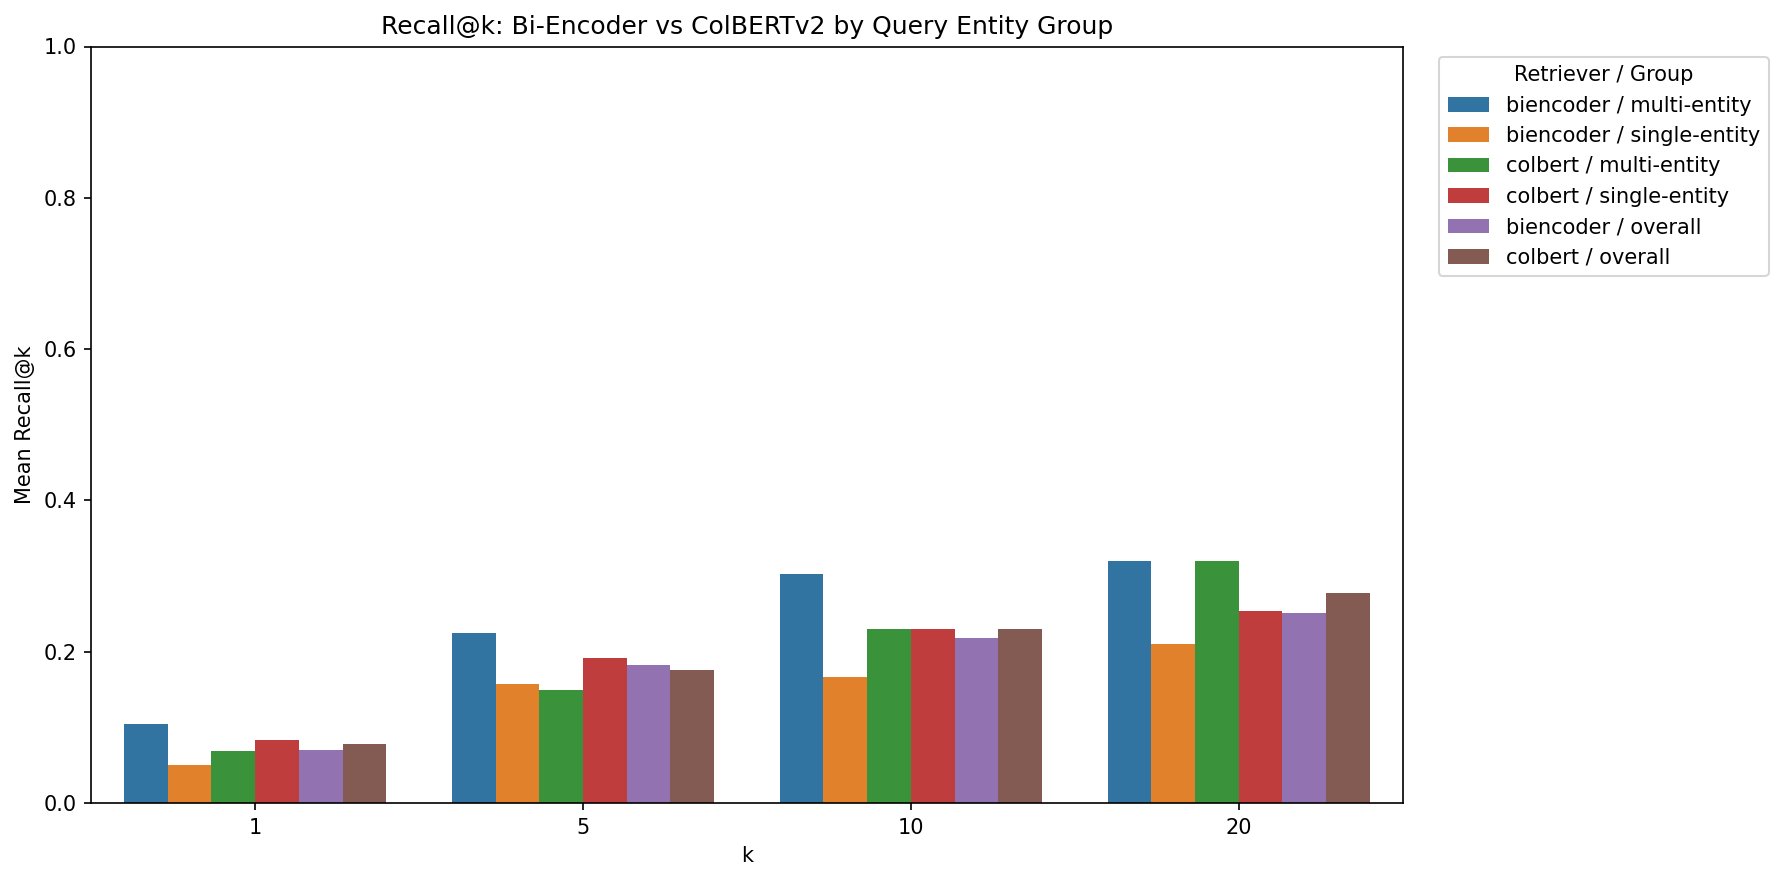


--- results/charts\recall_histogram_k1.png ---


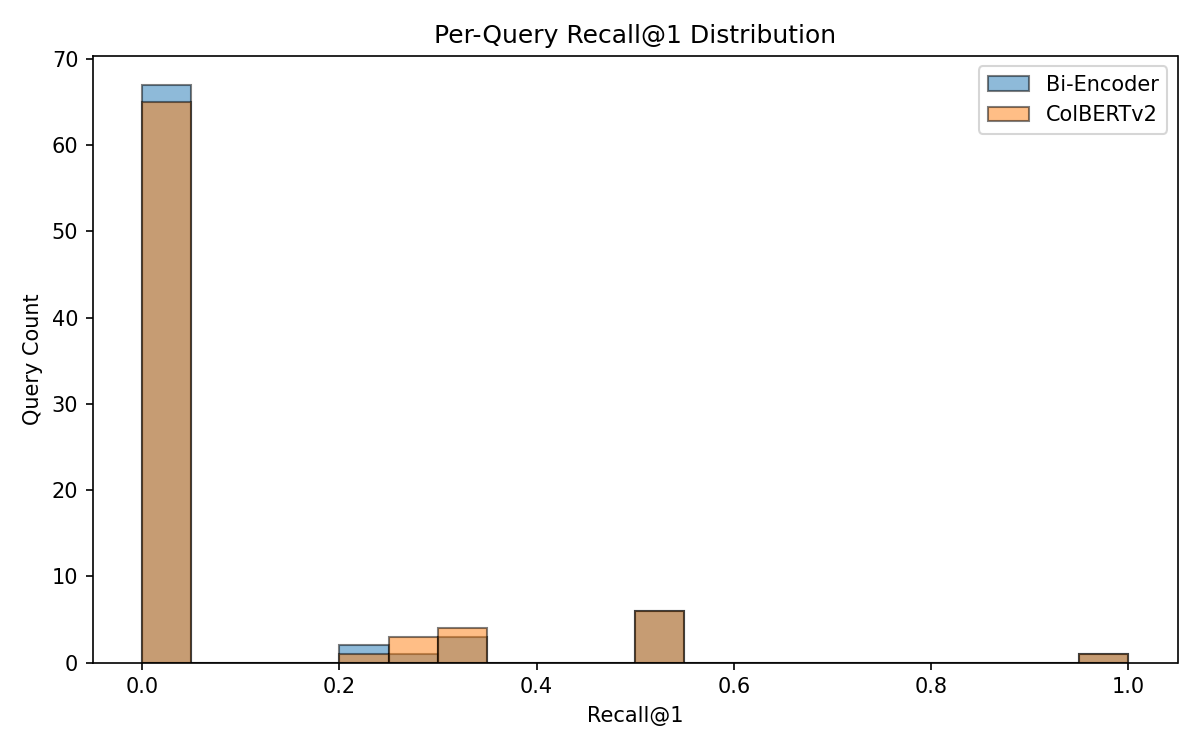


--- results/charts\recall_histogram_k5.png ---


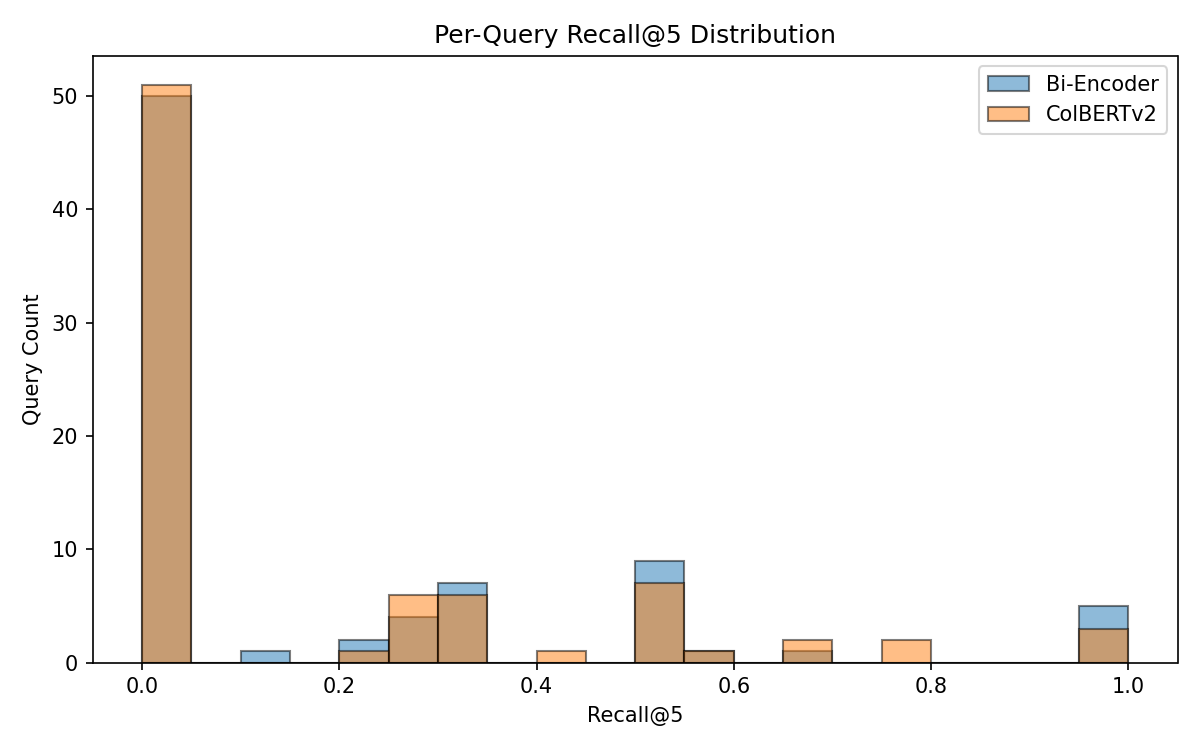


--- results/charts\recall_histogram_k10.png ---


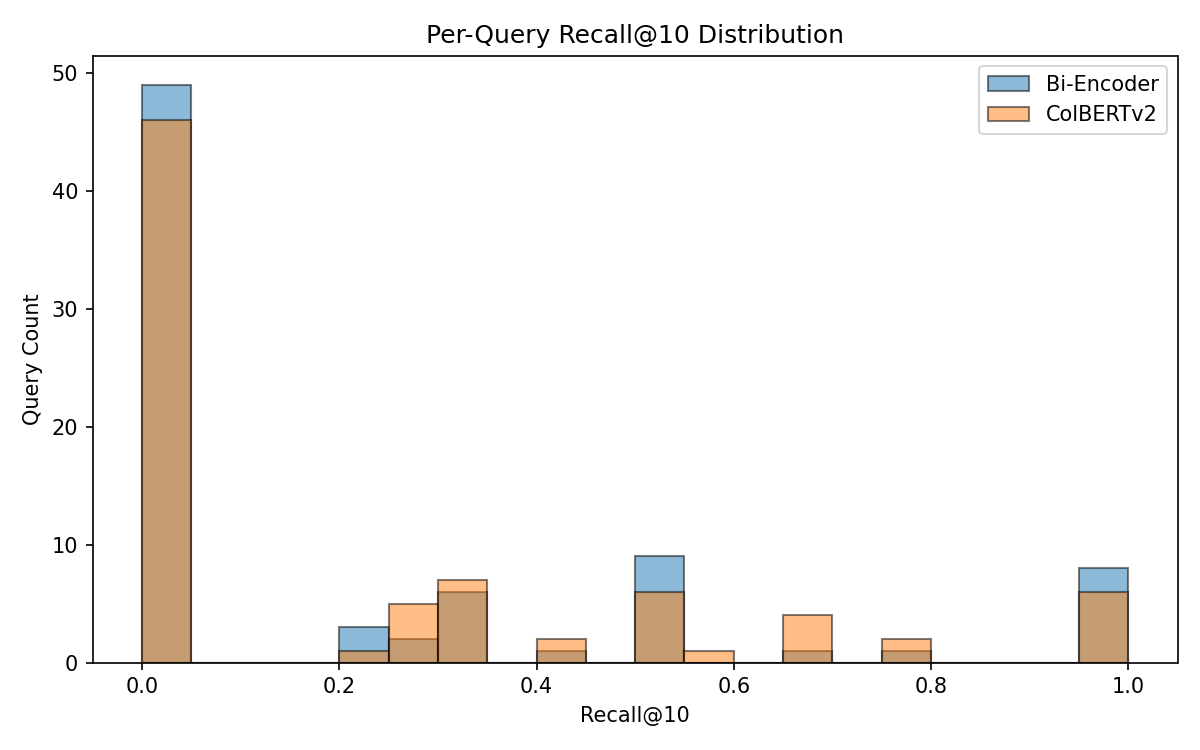


--- results/charts\recall_histogram_k20.png ---


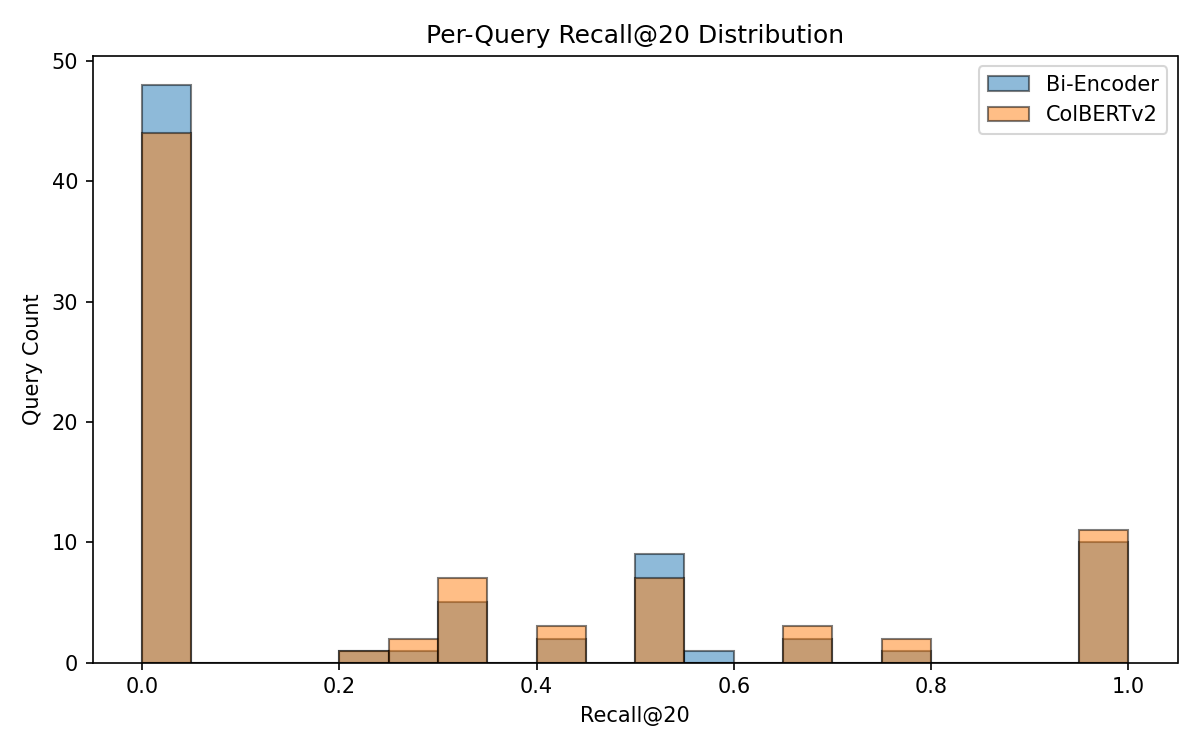


--- latency_comparison ---


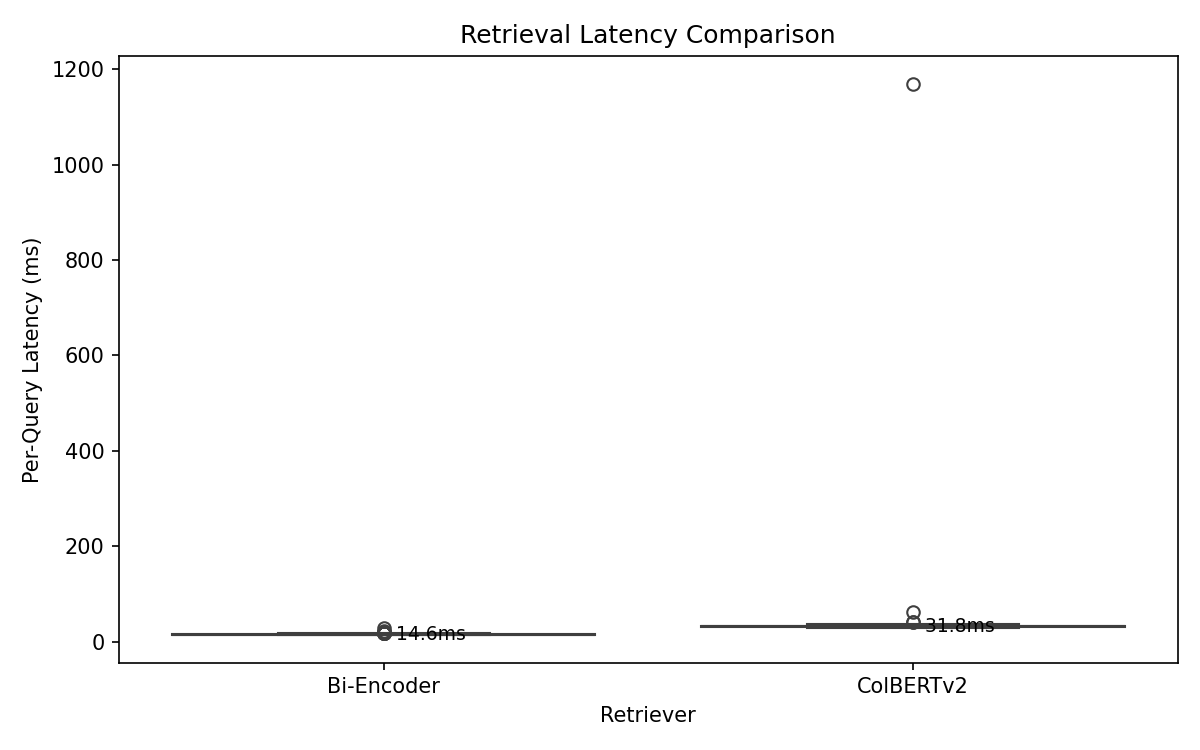


--- index_size_comparison ---


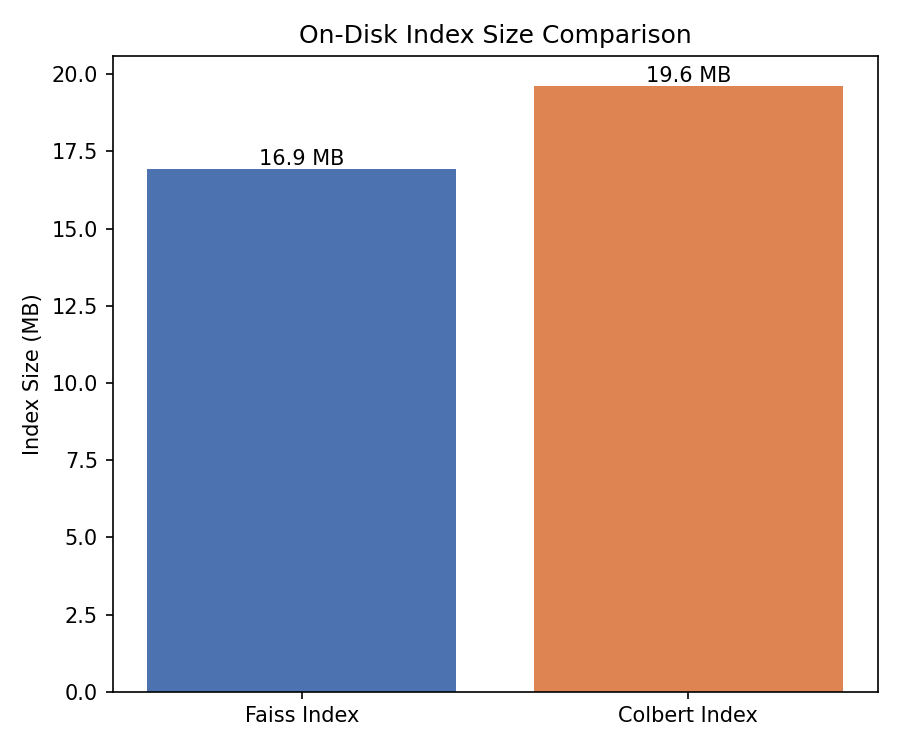

In [8]:
from IPython.display import Image, display

for name, path in output_paths.items():
    if isinstance(path, str) and path.endswith(".png"):
        print(f"\n--- {name} ---")
        display(Image(filename=path))
    elif isinstance(path, list):
        for p in path:
            print(f"\n--- {p} ---")
            display(Image(filename=p))

## 8. Profiling Summary

In [9]:
import json

with open(config["paths"]["json_log"], encoding="utf-8") as f:
    log = json.load(f)

print("=== Stage Timings ===")
for stage, info in log["stages"].items():
    vram = f", VRAM peak: {info['peak_vram_bytes']/1e9:.2f} GB" if info.get("peak_vram_bytes") else ""
    print(f"  {stage}: {info['duration_seconds']:.2f}s, RSS: {info['rss_bytes']/1e9:.2f} GB{vram}")

print(f"\n=== Disk Sizes ===")
for label, size in log["disk_sizes"].items():
    print(f"  {label}: {size/1e6:.1f} MB")

print(f"\n=== Run Metadata ===")
meta = log["metadata"]
print(f"  Timestamp: {meta['timestamp']}")
print(f"  GPU: {meta.get('gpu_device', 'None')}")
print(f"  Corpus size: {meta.get('corpus_size', 'N/A')} pages")
print(f"  Total chunks: {meta.get('total_chunks', 'N/A')}")
print(f"  Queries: {meta.get('total_queries', 'N/A')}")
print(f"  Queries per group: {meta.get('queries_per_group', 'N/A')}")

=== Stage Timings ===
  data_loading: 9.83s, RSS: 0.86 GB
  ner_classification: 2.86s, RSS: 0.89 GB
  query_sampling: 0.00s, RSS: 0.89 GB
  corpus_construction: 0.02s, RSS: 0.90 GB
  chunking: 0.24s, RSS: 0.90 GB
  biencoder_encoding: 23.75s, RSS: 2.15 GB, VRAM peak: 8.00 GB
  faiss_indexing: 0.24s, RSS: 2.15 GB, VRAM peak: 0.14 GB
  biencoder_retrieval: 1.25s, RSS: 2.13 GB, VRAM peak: 0.14 GB
  colbert_indexing: 282.94s, RSS: 0.70 GB, VRAM peak: 13.94 GB
  colbert_retrieval: 3.75s, RSS: 0.59 GB, VRAM peak: 1.09 GB

=== Disk Sizes ===
  faiss_index: 17.7 MB
  colbert_index: 20.6 MB

=== Run Metadata ===
  Timestamp: 2026-04-10T17:29:06.403005+00:00
  GPU: NVIDIA GeForce RTX 3070 Laptop GPU
  Corpus size: 422 pages
  Total chunks: 11555
  Queries: 80
  Queries per group: {'multi-entity': 30, 'single-entity': 50}


## 9. Strategy Sections

The sections below run one chunking strategy at a time and save outputs under `results/notebook/<variant>/`.
Each section is intentionally explicit so the workflow is easy to follow in presentation and debugging.


In [10]:
NOTEBOOK_VARIANTS = [
    "paragraph",
    "sentence_window",
    "adaptive_sentence",
    "semantic_similarity",
]

def show_saved_variant_outputs(label: str):
    summary_path = Path("results") / "notebook" / label / "summary_statistics.csv"
    charts_dir = Path("results") / "notebook" / label / "charts"

    if summary_path.exists():
        summary_df = pd.read_csv(summary_path)
        display(summary_df)
    else:
        print(f"No summary CSV found for {label}.")

    for image_name in ["recall_bar_chart.png", "latency_comparison.png", "index_size_comparison.png"]:
        image_path = charts_dir / image_name
        if image_path.exists():
            print(f"\n--- {label}: {image_name} ---")
            display(Image(filename=str(image_path)))


## 10. Sentence Window Benchmark


In [11]:
sentence_window_config = build_variant_config(
    config,
    run_subdir="notebook/sentence_window",
    overrides={
        "chunking": {
            "strategy": "sentence_window",
            "sentence_window_size": 3,
            "sentence_window_stride": 2,
        }
    },
    cache_suffix="sentence_window",
)

sentence_window_result = run_full_benchmark(sentence_window_config)
print(sentence_window_result["summary"].to_string(index=False))


Batches: 100%|██████████| 56/56 [00:11<00:00,  4.68it/s]


---- WARNING! You are using PLAID with an experimental replacement for FAISS for greater compatibility ----
This is a behaviour change from RAGatouille 0.8.0 onwards.
This works fine for most users and smallish datasets, but can be considerably slower than FAISS and could cause worse results in some situations.
If you're confident with FAISS working on your machine, pass use_faiss=True to revert to the FAISS-using behaviour.
--------------------


[Apr 10, 13:34:58] #> Note: Output directory results\notebook\sentence_window\colbert_index\colbert\indexes/colbert_benchmark already exists


[Apr 10, 13:34:58] #> Will delete 10 files already at results\notebook\sentence_window\colbert_index\colbert\indexes/colbert_benchmark in 20 seconds...
[Apr 10, 13:35:20] [0] 		 #> Encoding 14225 passages..
[Apr 10, 13:36:00] [0] 		 avg_doclen_est = 34.82221603393555 	 len(local_sample) = 14,225
[Apr 10, 13:36:00] [0] 		 Creating 8,192 partitions.
[Apr 10, 13:36:00] [0] 		 *Estimated* 495,346 embedding

0it [00:00, ?it/s]

[Apr 10, 13:39:24] [0] 		 #> Encoding 14225 passages..


1it [00:38, 38.70s/it]
100%|██████████| 1/1 [00:00<00:00, 91.64it/s]

...

100%|██████████| 1/1 [00:00<00:00, 595.87it/s]

[Apr 10, 13:40:04] #> Loading codes and residuals...



100%|██████████| 1/1 [00:00<00:00, 58.81it/s]

Searcher loaded!

#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: . how many hoops are used in a game of croquet, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  2129,  2116, 27669,  2015,  2024,  2109,  1999,  1037,
         2208,  1997, 13675,  2080, 12647,   102,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



  Starting LLM generation for 80 queries...
  Generation step finished.
 entity_group  k  biencoder_recall  colbert_recall     delta
single-entity  1          0.067333        0.089000  0.021667
single-entity  5          0.173667        0.183667  0.010000
single-entity 10          0.185333        0.225000  0.039667
single-entity 20          0.207333        0.246667  0.039333
 multi-entity  1          0.092778        0.058333 -0.034444
 multi-entity  5          0.209762        0.140317 -0.069444
 multi-entity 10          0.273968        0.229524 -0.044444
 multi-entity 20          0.308730        0.262063 -0.046667
      overall  1          0.076875        0.077500  0.000625
      overall  5          0.187202        0.167411 -0.019792
      overall 10          0.218571        0.226696  0.008125
      overall 20          0.245357        0.252440  0.007083


## 11. Adaptive Sentence Benchmark (Enhanced Boundary Scorer)


In [12]:
adaptive_sentence_config = build_variant_config(
    config,
    run_subdir="notebook/adaptive_sentence",
    overrides={
        "chunking": {
            "strategy": "adaptive_sentence",
            "adaptive_min_words": 80,
            "adaptive_max_words": 160,
            "adaptive_keyword_slack_words": 40,
            "adaptive_keyword_min_overlap": 1,
            "learned_boundary_hidden_dim": 32,
            "learned_boundary_epochs": 15,
            "learned_boundary_batch_size": 128,
            "learned_boundary_learning_rate": 0.001,
            "learned_boundary_split_threshold": 0.55,
        }
    },
    cache_suffix="adaptive_sentence",
)

adaptive_sentence_result = run_full_benchmark(adaptive_sentence_config)
print(adaptive_sentence_result["summary"].to_string(index=False))


Batches: 100%|██████████| 46/46 [00:09<00:00,  4.65it/s]


---- WARNING! You are using PLAID with an experimental replacement for FAISS for greater compatibility ----
This is a behaviour change from RAGatouille 0.8.0 onwards.
This works fine for most users and smallish datasets, but can be considerably slower than FAISS and could cause worse results in some situations.
If you're confident with FAISS working on your machine, pass use_faiss=True to revert to the FAISS-using behaviour.
--------------------


[Apr 10, 13:44:04] #> Note: Output directory results\notebook\adaptive_sentence\colbert_index\colbert\indexes/colbert_benchmark already exists


[Apr 10, 13:44:04] #> Will delete 10 files already at results\notebook\adaptive_sentence\colbert_index\colbert\indexes/colbert_benchmark in 20 seconds...
[Apr 10, 13:44:26] [0] 		 #> Encoding 11663 passages..
[Apr 10, 13:44:58] [0] 		 avg_doclen_est = 36.222843170166016 	 len(local_sample) = 11,663
[Apr 10, 13:44:58] [0] 		 Creating 8,192 partitions.
[Apr 10, 13:44:58] [0] 		 *Estimated* 422,467 embe

0it [00:00, ?it/s]

[Apr 10, 13:48:07] [0] 		 #> Encoding 11663 passages..


1it [00:32, 32.75s/it]
100%|██████████| 1/1 [00:00<00:00, 57.63it/s]

...

100%|██████████| 1/1 [00:00<00:00, 999.83it/s]

[Apr 10, 13:48:41] #> Loading codes and residuals...



100%|██████████| 1/1 [00:00<00:00, 75.20it/s]

Searcher loaded!

#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: . how many hoops are used in a game of croquet, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  2129,  2116, 27669,  2015,  2024,  2109,  1999,  1037,
         2208,  1997, 13675,  2080, 12647,   102,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



  Starting LLM generation for 80 queries...
  Generation step finished.
 entity_group  k  biencoder_recall  colbert_recall     delta
single-entity  1          0.050667        0.090667  0.040000
single-entity  5          0.151333        0.198667  0.047333
single-entity 10          0.167000        0.236667  0.069667
single-entity 20          0.210667        0.253333  0.042667
 multi-entity  1          0.103889        0.069444 -0.034444
 multi-entity  5          0.216429        0.135873 -0.080556
 multi-entity 10          0.303175        0.229524 -0.073651
 multi-entity 20          0.319841        0.313175 -0.006667
      overall  1          0.070625        0.082708  0.012083
      overall  5          0.175744        0.175119 -0.000625
      overall 10          0.218065        0.233988  0.015923
      overall 20          0.251607        0.275774  0.024167


## 12. Semantic Similarity Benchmark


In [13]:
semantic_similarity_config = build_variant_config(
    config,
    run_subdir="notebook/semantic_similarity",
    overrides={
        "chunking": {
            "strategy": "semantic_similarity",
            "semantic_model": "sentence-transformers/all-MiniLM-L6-v2",
            "semantic_similarity_threshold": 0.72,
            "semantic_min_words": 60,
            "semantic_max_words": 120,
            "semantic_min_sentences": 2,
            "semantic_max_sentences": 5,
        }
    },
    cache_suffix="semantic_similarity",
)

semantic_similarity_result = run_full_benchmark(semantic_similarity_config)
print(semantic_similarity_result["summary"].to_string(index=False))


Batches: 100%|██████████| 62/62 [00:10<00:00,  5.92it/s]


---- WARNING! You are using PLAID with an experimental replacement for FAISS for greater compatibility ----
This is a behaviour change from RAGatouille 0.8.0 onwards.
This works fine for most users and smallish datasets, but can be considerably slower than FAISS and could cause worse results in some situations.
If you're confident with FAISS working on your machine, pass use_faiss=True to revert to the FAISS-using behaviour.
--------------------


[Apr 10, 13:54:14] #> Note: Output directory results\notebook\semantic_similarity\colbert_index\colbert\indexes/colbert_benchmark already exists


[Apr 10, 13:54:14] #> Will delete 10 files already at results\notebook\semantic_similarity\colbert_index\colbert\indexes/colbert_benchmark in 20 seconds...
[Apr 10, 13:54:35] [0] 		 #> Encoding 15726 passages..
[Apr 10, 13:55:13] [0] 		 avg_doclen_est = 28.262557983398438 	 len(local_sample) = 15,726
[Apr 10, 13:55:14] [0] 		 Creating 8,192 partitions.
[Apr 10, 13:55:14] [0] 		 *Estimated* 444,456 

0it [00:00, ?it/s]

[Apr 10, 13:58:27] [0] 		 #> Encoding 15726 passages..


1it [00:39, 39.27s/it]
100%|██████████| 1/1 [00:00<00:00, 69.75it/s]

...

100%|██████████| 1/1 [00:00<00:00, 998.88it/s]

[Apr 10, 13:59:08] #> Loading codes and residuals...



100%|██████████| 1/1 [00:00<00:00, 59.85it/s]

Searcher loaded!

#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: . how many hoops are used in a game of croquet, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  2129,  2116, 27669,  2015,  2024,  2109,  1999,  1037,
         2208,  1997, 13675,  2080, 12647,   102,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



  Starting LLM generation for 80 queries...
  Generation step finished.
 entity_group  k  biencoder_recall  colbert_recall     delta
single-entity  1          0.062333        0.094000  0.031667
single-entity  5          0.167000        0.176000  0.009000
single-entity 10          0.180333        0.220000  0.039667
single-entity 20          0.205000        0.240667  0.035667
 multi-entity  1          0.092778        0.058333 -0.034444
 multi-entity  5          0.234762        0.155317 -0.079444
 multi-entity 10          0.277063        0.180317 -0.096746
 multi-entity 20          0.308730        0.285397 -0.023333
      overall  1          0.073750        0.080625  0.006875
      overall  5          0.192411        0.168244 -0.024167
      overall 10          0.216607        0.205119 -0.011488
      overall 20          0.243899        0.257440  0.013542


## 13. Compare Variant Summaries


In [14]:
variant_rows = []

for label in NOTEBOOK_VARIANTS:
    if label == "paragraph":
        summary_path = Path("results") / "summary_statistics.csv"
    else:
        summary_path = Path("results") / "notebook" / label / "summary_statistics.csv"

    if not summary_path.exists():
        continue

    summary_df = pd.read_csv(summary_path)
    overall = summary_df[summary_df["entity_group"] == "overall"].copy()

    row = {"variant": label}
    for _, metric_row in overall.iterrows():
        k = int(metric_row["k"])
        row[f"biencoder_recall_at_{k}"] = metric_row["biencoder_recall"]
        row[f"colbert_recall_at_{k}"] = metric_row["colbert_recall"]
        row[f"delta_at_{k}"] = metric_row["delta"]

    variant_rows.append(row)

variant_overview = pd.DataFrame(variant_rows)
variant_overview


,variant,biencoder_recall_at_1,colbert_recall_at_1,delta_at_1,biencoder_recall_at_5,colbert_recall_at_5,delta_at_5,biencoder_recall_at_10,colbert_recall_at_10,delta_at_10,biencoder_recall_at_20,colbert_recall_at_20,delta_at_20
0,paragraph,0.070625,0.078542,0.007917,0.183036,0.175863,-0.007173,0.218065,0.229821,0.011756,0.251607,0.278274,0.026667
1,sentence_window,0.076875,0.077500,0.000625,0.187202,0.167411,-0.019792,0.218571,0.226696,0.008125,0.245357,0.252440,0.007083
2,adaptive_sentence,0.070625,0.082708,0.012083,0.175744,0.175119,-0.000625,0.218065,0.233988,0.015923,0.251607,0.275774,0.024167
3,semantic_similarity,0.073750,0.080625,0.006875,0.192411,0.168244,-0.024167,0.216607,0.205119,-0.011488,0.243899,0.257440,0.013542


## 14. Display Saved Results for Any Variant

Set `SELECTED_VARIANT` to inspect any completed run without rerunning the strategy cell.


,entity_group,k,biencoder_recall,colbert_recall,delta
0,single-entity,1,0.050667,0.090667,0.040000
1,single-entity,5,0.151333,0.198667,0.047333
2,single-entity,10,0.167000,0.236667,0.069667
3,single-entity,20,0.210667,0.253333,0.042667
4,multi-entity,1,0.103889,0.069444,-0.034444
5,multi-entity,5,0.216429,0.135873,-0.080556
6,multi-entity,10,0.303175,0.229524,-0.073651
7,multi-entity,20,0.319841,0.313175,-0.006667
8,overall,1,0.070625,0.082708,0.012083
9,overall,5,0.175744,0.175119,-0.000625



--- adaptive_sentence: recall_bar_chart.png ---


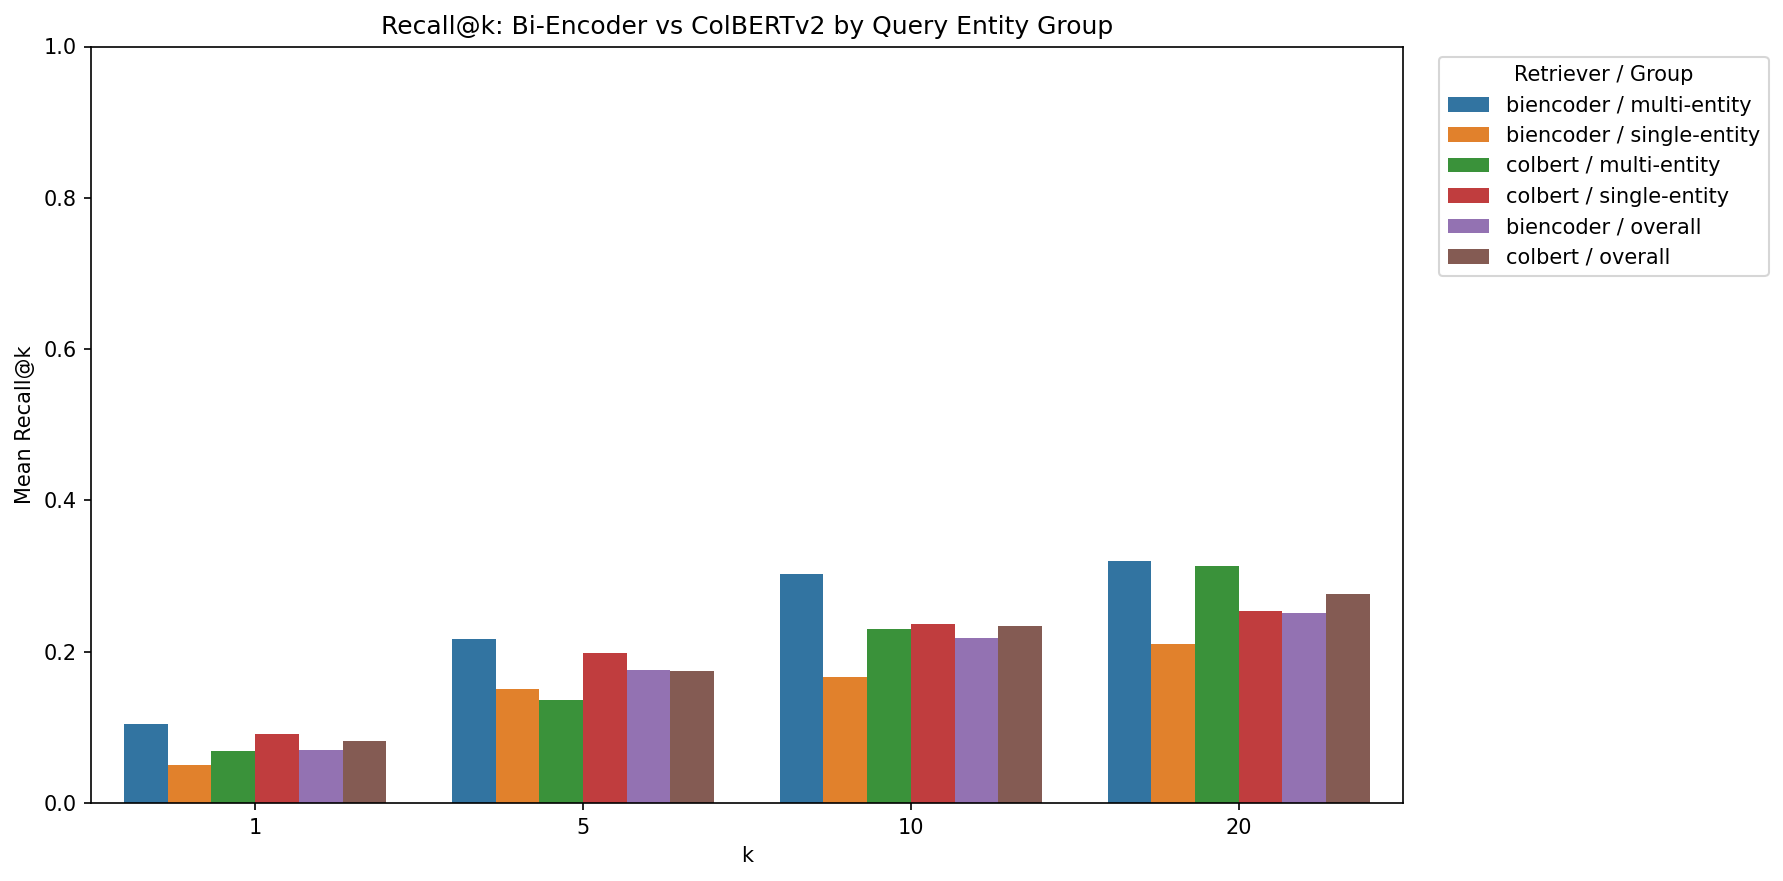


--- adaptive_sentence: latency_comparison.png ---


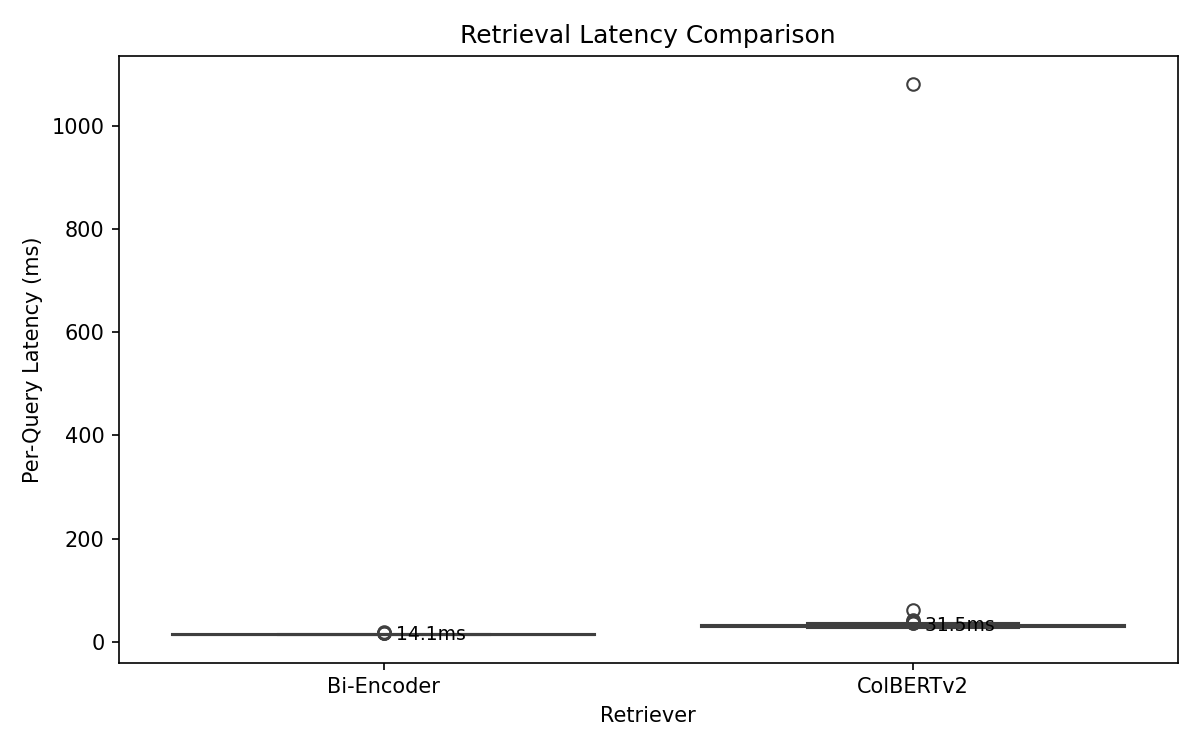


--- adaptive_sentence: index_size_comparison.png ---


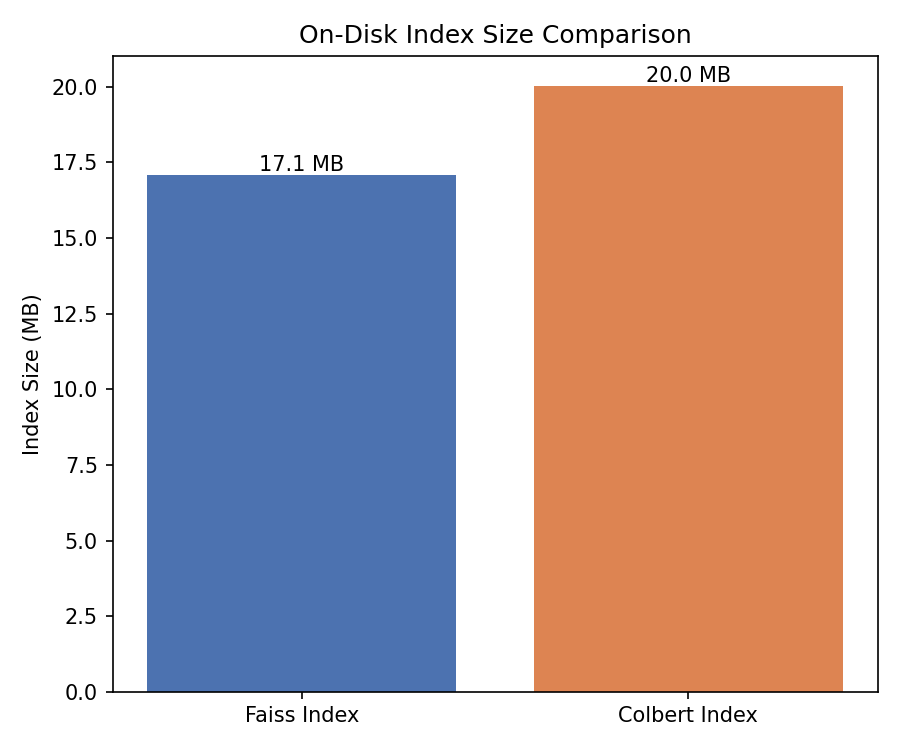

In [15]:
SELECTED_VARIANT = "adaptive_sentence"
show_saved_variant_outputs(SELECTED_VARIANT)


## 15. Error Analysis

Compare two completed variants at query level. This section is intended for focused qualitative analysis rather than rerunning the whole benchmark.


In [16]:
from src.error_analysis import compare_variant_logs, summarize_comparison

BASELINE_VARIANT = "paragraph"
CANDIDATE_VARIANT = "adaptive_sentence"
ERROR_ANALYSIS_RETRIEVER = "colbert"
ERROR_ANALYSIS_K = 10

baseline_log_path = (
    Path("results") / "benchmark_log.json"
    if BASELINE_VARIANT == "paragraph"
    else Path("results") / "notebook" / BASELINE_VARIANT / "benchmark_log.json"
)

candidate_log_path = Path("results") / "notebook" / CANDIDATE_VARIANT / "benchmark_log.json"

comparison = compare_variant_logs(
    baseline_log_path=str(baseline_log_path),
    candidate_log_path=str(candidate_log_path),
    retriever=ERROR_ANALYSIS_RETRIEVER,
    k=ERROR_ANALYSIS_K,
)

print(summarize_comparison(comparison).to_string(index=False))
comparison.head(10)

 entity_group   outcome  count  mean_delta
 multi-entity unchanged     30    0.000000
single-entity  improved      1    0.333333
single-entity unchanged     49    0.000000


,query,entity_group,ground_truth_chunk_ids,baseline_recall,candidate_recall,delta,outcome,baseline_top_5,candidate_top_5
0,what was the meaning of the song puff the magi...,single-entity,"[158197_5, 158197_9, 158197_0]",0.666667,1.000000,0.333333,improved,"[158197_1, 158197_4, 158197_24, 158197_14, 158...","[158197_9_c1, 158197_1_c0, 158197_4_c0, 158197..."
1,an influential religion to enter china along t...,multi-entity,"[1471955_48, 9704619_1, 226808_5, 226808_6, 22...",0.285714,0.285714,0.000000,unchanged,"[1471955_9, 1471955_1, 226808_6, 1471955_66, 1...","[1471955_9_c0, 1471955_1_c0, 226808_6_c0, 1471..."
2,atlantic ocean's shape is similar to which eng...,multi-entity,"[698_2, 698_0]",1.000000,1.000000,0.000000,unchanged,"[698_2, 698_8, 698_5, 698_6, 698_40]","[698_2_c0, 698_8_c0, 698_5_c0, 698_6_c0, 698_4..."
3,how many games in a row have the uconn women's...,single-entity,[16849464_3],0.000000,0.000000,0.000000,unchanged,"[37467594_1, 38318461_25, 38318461_9, 38318461...","[37467594_1_c0, 38318461_25_c0, 6643_36_c0, 66..."
4,how many hoops are used in a game of croquet,single-entity,"[6643_26, 6643_16, 6643_51, 6643_0]",0.750000,0.750000,0.000000,unchanged,"[6643_26, 6643_51, 6643_16, 6643_39, 6643_1]","[6643_26_c0, 6643_51_c0, 6643_39_c0, 6643_16_c..."
5,joined mexico and the united states to form nafta,multi-entity,"[14526318_4, 14526318_0, 58620732_1]",0.000000,0.000000,0.000000,unchanged,"[3850_55, 2812172_4, 2812172_25, 52447_44, 523...","[3850_55_c0, 2812172_4_c0, 38318461_25_c0, 281..."
6,list of books written by abul kalam azad,single-entity,"[676919_17, 676919_23, 676919_0]",0.000000,0.000000,0.000000,unchanged,"[9735593_6, 3850_118, 13212863_33, 9735593_4, ...","[13212863_33_c0, 226808_25_c0, 3850_118_c0, 97..."
7,nuclear power plant that blew up in russia,single-entity,"[2589713_0, 1238999_2, 2589713_1]",0.333333,0.333333,0.000000,unchanged,"[1238999_4, 1238999_1, 2589713_10, 2589713_1, ...","[1238999_4_c0, 1238999_1_c0, 2589713_10_c0, 25..."
8,prior to 1948 north and south vietnam were a p...,multi-entity,"[34976514_9, 34976514_0, 34976514_1]",0.666667,0.666667,0.000000,unchanged,"[34976514_1, 34976514_20, 34976514_9, 34976514...","[34976514_1_c0, 34976514_20_c0, 34976514_9_c0,..."
9,the first vice president of india who become t...,multi-entity,"[12559103_3, 12559103_0, 22905775_1]",0.000000,0.000000,0.000000,unchanged,"[19242288_15, 51140466_4, 24858513_9, 24971127...","[24971127_4_c1, 51140466_4_c0, 19242288_15_c0,..."


## 16. Knowledge Graph Prototype

Build and evaluate the lightweight entity graph baseline using the current config.


In [17]:
from src.knowledge_graph import build_graph_from_config, graph_summary_dataframe, run_graph_retrieval, save_graph

kg_config = load_config("configs/experiment_config.yaml")
kg_output_dir = Path("results") / "notebook" / "knowledge_graph"
kg_output_dir.mkdir(parents=True, exist_ok=True)

kg_built = build_graph_from_config(kg_config)
graph = kg_built["graph"]
kg_queries = kg_built["sampled_queries"]

save_graph(graph, str(kg_output_dir / "knowledge_graph.json"))
run_graph_retrieval(
    graph=graph,
    sampled_queries=kg_queries,
    k_values=kg_config["retrieval"]["k_values"],
    spacy_model=kg_config["spacy"]["model"],
)

graph_summary = graph_summary_dataframe(kg_queries)
graph_summary.to_csv(kg_output_dir / "graph_recall_summary.csv", index=False)
print(graph_summary.to_string(index=False))


 entity_group  k  graph_recall
 multi-entity  1      0.000000
 multi-entity  5      0.065873
 multi-entity 10      0.083651
 multi-entity 20      0.121984
single-entity  1      0.000000
single-entity  5      0.000000
single-entity 10      0.000000
single-entity 20      0.000000
      overall  1      0.000000
      overall  5      0.024702
      overall 10      0.031369
      overall 20      0.045744


## 17. Hybrid Retrieval (Adaptive Sentence + Dense / ColBERT + KG)

Run lightweight hybrid baselines by combining dense rankings with graph retrieval using reciprocal rank fusion.


In [18]:
from src.data_pipeline import run_data_pipeline
from src.profiler import Profiler
from src.biencoder_retrieval import run_biencoder_retrieval
from src.colbert_retrieval import run_colbert_retrieval
from src.knowledge_graph import build_knowledge_graph, run_graph_retrieval, graph_summary_dataframe, save_graph
from src.hybrid_retrieval import run_hybrid_retrieval, run_selective_hybrid_retrieval, hybrid_summary_dataframe

hybrid_config = build_variant_config(
    config,
    run_subdir="notebook/colbert_graph_hybrid",
    overrides={
        "chunking": {
            "strategy": "adaptive_sentence",
            "adaptive_min_words": 80,
            "adaptive_max_words": 160,
        }
    },
    cache_suffix="colbert_graph_hybrid",
)

hybrid_profiler = Profiler(config=hybrid_config)
hybrid_pipeline = run_data_pipeline(hybrid_config, hybrid_profiler)
hybrid_chunks = hybrid_pipeline["chunks"]
hybrid_queries = hybrid_pipeline["sampled_queries"]

run_biencoder_retrieval(hybrid_chunks, hybrid_queries, hybrid_config, hybrid_profiler)
run_colbert_retrieval(hybrid_chunks, hybrid_queries, hybrid_config, hybrid_profiler)

hybrid_graph = build_knowledge_graph(hybrid_chunks, spacy_model=hybrid_config["spacy"]["model"])

hybrid_output_dir = Path(hybrid_config["paths"]["results_dir"])
hybrid_output_dir.mkdir(parents=True, exist_ok=True)

run_graph_retrieval(
    graph=hybrid_graph,
    sampled_queries=hybrid_queries,
    k_values=hybrid_config["retrieval"]["k_values"],
    spacy_model=hybrid_config["spacy"]["model"],
)

colbert_graph_weight_sweep = []
for graph_weight in [0.2, 0.4, 0.6, 0.7]:
    sweep_prefix = f"colbert_graph_rrf_g{str(graph_weight).replace('.', '')}"
    run_hybrid_retrieval(
        hybrid_queries,
        primary_key="colbert",
        graph_key="graph",
        output_prefix=sweep_prefix,
        k_values=hybrid_config["retrieval"]["k_values"],
        primary_weight=1.0,
        graph_weight=graph_weight,
        rrf_k=60,
    )
    sweep_summary = hybrid_summary_dataframe(hybrid_queries, sweep_prefix)
    sweep_summary.to_csv(hybrid_output_dir / f"{sweep_prefix}_summary.csv", index=False)
    overall_df = sweep_summary[sweep_summary["entity_group"] == "overall"].copy()
    row = {"system": sweep_prefix, "graph_weight": graph_weight}
    for _, metric_row in overall_df.iterrows():
        row[f"recall_at_{int(metric_row['k'])}"] = metric_row["hybrid_recall"]
    colbert_graph_weight_sweep.append(row)

run_hybrid_retrieval(
    hybrid_queries,
    primary_key="biencoder",
    graph_key="graph",
    output_prefix="biencoder_graph_hybrid",
    k_values=hybrid_config["retrieval"]["k_values"],
    primary_weight=1.0,
    graph_weight=0.7,
    rrf_k=60,
)

run_hybrid_retrieval(
    hybrid_queries,
    primary_key="colbert",
    graph_key="graph",
    output_prefix="colbert_graph_hybrid",
    k_values=hybrid_config["retrieval"]["k_values"],
    primary_weight=1.0,
    graph_weight=0.7,
    rrf_k=60,
)

run_selective_hybrid_retrieval(
    hybrid_queries,
    primary_key="colbert",
    graph_key="graph",
    output_prefix="colbert_graph_selective",
    k_values=hybrid_config["retrieval"]["k_values"],
    fuse_entity_groups={"multi-entity"},
    primary_weight=1.0,
    graph_weight=0.7,
    rrf_k=60,
)

save_graph(hybrid_graph, str(hybrid_output_dir / "knowledge_graph.json"))

graph_summary = graph_summary_dataframe(hybrid_queries)
graph_summary.to_csv(hybrid_output_dir / "graph_recall_summary.csv", index=False)

biencoder_hybrid_summary = hybrid_summary_dataframe(hybrid_queries, "biencoder_graph_hybrid")
biencoder_hybrid_summary.to_csv(hybrid_output_dir / "biencoder_graph_hybrid_summary.csv", index=False)

colbert_hybrid_summary = hybrid_summary_dataframe(hybrid_queries, "colbert_graph_hybrid")
colbert_hybrid_summary.to_csv(hybrid_output_dir / "colbert_graph_hybrid_summary.csv", index=False)

colbert_selective_summary = hybrid_summary_dataframe(hybrid_queries, "colbert_graph_selective")
colbert_selective_summary.to_csv(hybrid_output_dir / "colbert_graph_selective_summary.csv", index=False)

hybrid_compare_rows = []
for source_name, summary_df in [
    ("graph", graph_summary.rename(columns={"graph_recall": "recall"})),
    ("biencoder_graph_hybrid", biencoder_hybrid_summary.rename(columns={"hybrid_recall": "recall"})),
    ("colbert_graph_hybrid", colbert_hybrid_summary.rename(columns={"hybrid_recall": "recall"})),
    ("colbert_graph_selective", colbert_selective_summary.rename(columns={"hybrid_recall": "recall"})),
]:
    overall_df = summary_df[summary_df["entity_group"] == "overall"]
    row = {"system": source_name}
    for _, metric_row in overall_df.iterrows():
        row[f"recall_at_{int(metric_row['k'])}"] = metric_row["recall"]
    hybrid_compare_rows.append(row)

hybrid_compare = pd.DataFrame(hybrid_compare_rows)
hybrid_compare.to_csv(hybrid_output_dir / "hybrid_compare_overall.csv", index=False)
weight_sweep_df = pd.DataFrame(colbert_graph_weight_sweep)
weight_sweep_df.to_csv(hybrid_output_dir / "colbert_graph_weight_sweep.csv", index=False)

print("Graph summary:")
print(graph_summary.to_string(index=False))
print("\nBi-encoder + Graph hybrid summary:")
print(biencoder_hybrid_summary.to_string(index=False))
print("\nColBERT + Graph hybrid summary:")
print(colbert_hybrid_summary.to_string(index=False))
print("\nColBERT + Graph selective hybrid summary:")
print(colbert_selective_summary.to_string(index=False))
print("\nColBERT + Graph weight sweep (overall):")
print(weight_sweep_df.to_string(index=False))
print("\nOverall hybrid comparison:")
print(hybrid_compare.to_string(index=False))


Batches: 100%|██████████| 46/46 [00:09<00:00,  4.71it/s]


---- WARNING! You are using PLAID with an experimental replacement for FAISS for greater compatibility ----
This is a behaviour change from RAGatouille 0.8.0 onwards.
This works fine for most users and smallish datasets, but can be considerably slower than FAISS and could cause worse results in some situations.
If you're confident with FAISS working on your machine, pass use_faiss=True to revert to the FAISS-using behaviour.
--------------------


[Apr 10, 14:05:16] #> Note: Output directory results\notebook\colbert_graph_hybrid\colbert_index\colbert\indexes/colbert_benchmark already exists


[Apr 10, 14:05:16] #> Will delete 10 files already at results\notebook\colbert_graph_hybrid\colbert_index\colbert\indexes/colbert_benchmark in 20 seconds...
[Apr 10, 14:05:37] [0] 		 #> Encoding 11663 passages..
[Apr 10, 14:06:09] [0] 		 avg_doclen_est = 36.21315383911133 	 len(local_sample) = 11,663
[Apr 10, 14:06:09] [0] 		 Creating 8,192 partitions.
[Apr 10, 14:06:09] [0] 		 *Estimated* 422,354

0it [00:00, ?it/s]

[Apr 10, 14:09:07] [0] 		 #> Encoding 11663 passages..


1it [00:32, 32.50s/it]
100%|██████████| 1/1 [00:00<00:00, 60.71it/s]

...

100%|██████████| 1/1 [00:00<00:00, 1000.31it/s]

[Apr 10, 14:09:41] #> Loading codes and residuals...



100%|██████████| 1/1 [00:00<00:00, 68.73it/s]

Searcher loaded!

#> QueryTokenizer.tensorize(batch_text[0], batch_background[0], bsize) ==
#> Input: . how many hoops are used in a game of croquet, 		 True, 		 None
#> Output IDs: torch.Size([32]), tensor([  101,     1,  2129,  2116, 27669,  2015,  2024,  2109,  1999,  1037,
         2208,  1997, 13675,  2080, 12647,   102,   103,   103,   103,   103,
          103,   103,   103,   103,   103,   103,   103,   103,   103,   103,
          103,   103], device='cuda:0')
#> Output Mask: torch.Size([32]), tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')



Graph summary:
 entity_group  k  graph_recall
 multi-entity  1      0.008333
 multi-entity  5      0.076984
 multi-entity 10      0.100317
 multi-entity 20      0.115317
single-entity  1      0.000000
single-entity  5      0.000000
single-entity 10      0.000000
single-entity 20      0.004000
      overall  1      0.003125
      overall  5      0.028869
      overall 10      0.037619
      overall 20      0.045744

Bi-encoder + Graph hybrid summary:
 entity_group  k  hybrid_recall
 multi-entity  1       0.103889
 multi-entity  5       0.187540
 multi-entity 10       0.261190
 multi-entity 20       0.319841
single-entity  1       0.054667
single-entity  5       0.155333
single-entity 10       0.171000
single-entity 20       0.210667
      overall  1       0.073125
      overall  5       0.167411
      overall 10       0.204821
      overall 20       0.251607

ColBERT + Graph hybrid summary:
 entity_group  k  hybrid_recall
 multi-entity  1       0.044444
 multi-entity  5       0.119762
 

## 18. Project Comparison Charts

Build compact comparison tables for both chunking strategies and hybrid retrieval, then visualize the main takeaways.


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

variant_rows = []
for label in NOTEBOOK_VARIANTS:
    if label == "paragraph":
        summary_path = Path("results") / "summary_statistics.csv"
    else:
        summary_path = Path("results") / "notebook" / label / "summary_statistics.csv"

    if not summary_path.exists():
        continue

    summary_df = pd.read_csv(summary_path)
    overall = summary_df[summary_df["entity_group"] == "overall"].copy()

    row = {"variant": label}
    for _, metric_row in overall.iterrows():
        k = int(metric_row["k"])
        row[f"biencoder_recall_at_{k}"] = metric_row["biencoder_recall"]
        row[f"colbert_recall_at_{k}"] = metric_row["colbert_recall"]
        row[f"delta_at_{k}"] = metric_row["delta"]
    variant_rows.append(row)

variant_overview = pd.DataFrame(variant_rows)

hybrid_compare_path = Path("results") / "notebook" / "colbert_graph_hybrid" / "hybrid_compare_overall.csv"
hybrid_overview = pd.read_csv(hybrid_compare_path) if hybrid_compare_path.exists() else pd.DataFrame()

print("Chunking overview:")
display(variant_overview)
print("Hybrid overview:")
display(hybrid_overview)


Chunking overview:


,variant,biencoder_recall_at_1,colbert_recall_at_1,delta_at_1,biencoder_recall_at_5,colbert_recall_at_5,delta_at_5,biencoder_recall_at_10,colbert_recall_at_10,delta_at_10,biencoder_recall_at_20,colbert_recall_at_20,delta_at_20
0,paragraph,0.070625,0.078542,0.007917,0.183036,0.175863,-0.007173,0.218065,0.229821,0.011756,0.251607,0.278274,0.026667
1,sentence_window,0.076875,0.077500,0.000625,0.187202,0.167411,-0.019792,0.218571,0.226696,0.008125,0.245357,0.252440,0.007083
2,adaptive_sentence,0.070625,0.082708,0.012083,0.175744,0.175119,-0.000625,0.218065,0.233988,0.015923,0.251607,0.275774,0.024167
3,semantic_similarity,0.073750,0.080625,0.006875,0.192411,0.168244,-0.024167,0.216607,0.205119,-0.011488,0.243899,0.257440,0.013542


Hybrid overview:


,system,recall_at_1,recall_at_5,recall_at_10,recall_at_20
0,graph,0.003125,0.028869,0.037619,0.045744
1,biencoder_graph_hybrid,0.073125,0.167411,0.204821,0.251607
2,colbert_graph_hybrid,0.069167,0.169077,0.237738,0.275774
3,colbert_graph_selective,0.069167,0.169077,0.237738,0.275774


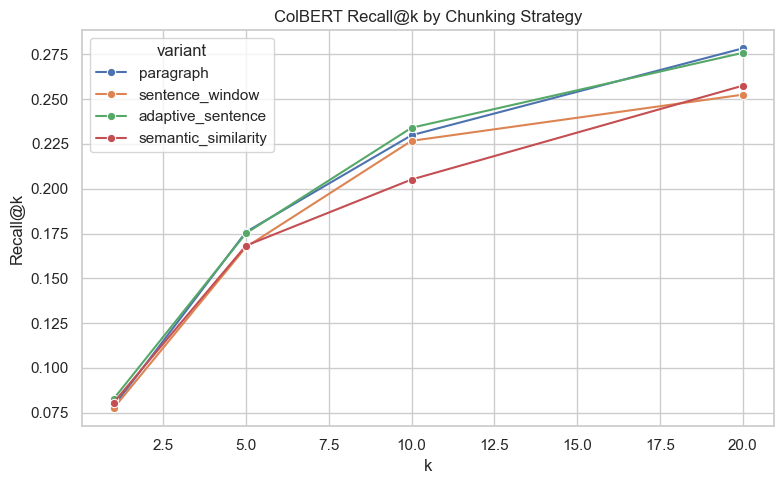

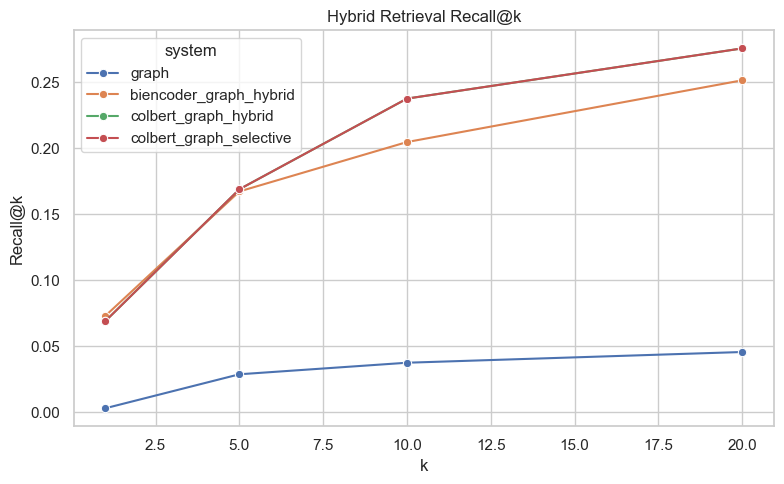

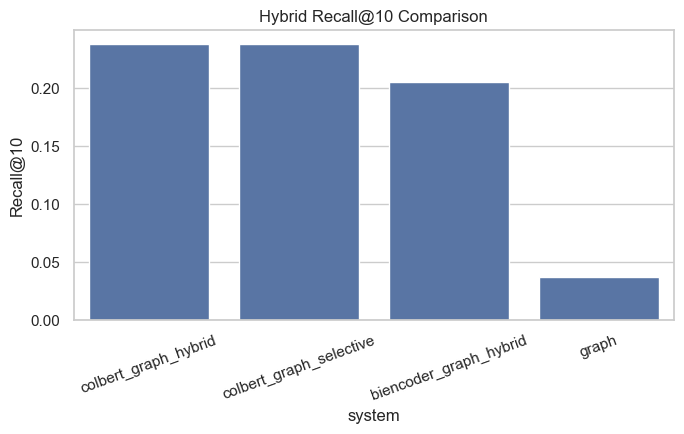

In [20]:
comparison_chart_dir = Path("results") / "notebook" / "final_comparison_charts"
comparison_chart_dir.mkdir(parents=True, exist_ok=True)

if not variant_overview.empty:
    chunk_chart_df = variant_overview.melt(
        id_vars=["variant"],
        value_vars=["colbert_recall_at_1", "colbert_recall_at_5", "colbert_recall_at_10", "colbert_recall_at_20"],
        var_name="metric",
        value_name="recall",
    )
    chunk_chart_df["k"] = chunk_chart_df["metric"].str.extract(r"(\d+)").astype(int)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.lineplot(data=chunk_chart_df, x="k", y="recall", hue="variant", marker="o", ax=ax)
    ax.set_title("ColBERT Recall@k by Chunking Strategy")
    ax.set_xlabel("k")
    ax.set_ylabel("Recall@k")
    fig.tight_layout()
    fig.savefig(comparison_chart_dir / "chunking_colbert_recall.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No completed variant summaries found yet.")

if not hybrid_overview.empty:
    hybrid_chart_df = hybrid_overview.melt(
        id_vars=["system"],
        value_vars=["recall_at_1", "recall_at_5", "recall_at_10", "recall_at_20"],
        var_name="metric",
        value_name="recall",
    )
    hybrid_chart_df["k"] = hybrid_chart_df["metric"].str.extract(r"(\d+)").astype(int)

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.lineplot(data=hybrid_chart_df, x="k", y="recall", hue="system", marker="o", ax=ax)
    ax.set_title("Hybrid Retrieval Recall@k")
    ax.set_xlabel("k")
    ax.set_ylabel("Recall@k")
    fig.tight_layout()
    fig.savefig(comparison_chart_dir / "hybrid_recall.png", dpi=150, bbox_inches="tight")
    plt.show()

    recall10 = hybrid_overview[["system", "recall_at_10"]].copy().sort_values("recall_at_10", ascending=False)
    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.barplot(data=recall10, x="system", y="recall_at_10", ax=ax)
    ax.set_title("Hybrid Recall@10 Comparison")
    ax.set_xlabel("system")
    ax.set_ylabel("Recall@10")
    ax.tick_params(axis="x", rotation=20)
    fig.tight_layout()
    fig.savefig(comparison_chart_dir / "hybrid_recall_at_10.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Hybrid comparison results not found yet.")
